# RT-TDKS calculations with ground-state KS wavefunctions as a basis
**by <span style="color:darkgreen">Dmitry Tumakov</span> & <span style="color:darkgreen">Ronaldo Rodrigues Pela</span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial, you will learn how to use ground-state **KS** wavefunctions as a basis set for time propagation of **KS** states. The independent particle approximation (**IPA**) is used, and two examples are considered: diamond crystal and monolayer BN.

<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Introduction](#1)
        
[2. Diamond crystal](#2)
    
  - [2.1 Ground-state calculation](#2.1)
    - [2.1.1 Preparation of the input file](#2.1.1)
    - [2.1.2 Running the ground-state calculation](#2.1.2)
    
  - [2.2 Performing a RT-TDDFT Calculation](#2.2)
    
    - [2.2.1 Calculations with **LAPW+LO** basis set](#2.2.1)
    - [2.2.2 Calculations with **KS** basis set](#2.2.2)
    - [2.2.3 Varying **KS** basis size](#2.2.3)

[3. Monolayer BN](#3)

  - [3.1 Ground-state calculation](#3.1)
  - [3.2 Monolayer BN exposed to a laser pulse](#3.2)
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>


**<span style="color:firebrick">Important note:</span>** All input parameters will be given in **atomic units**! For this tutorial, it can be useful to remind the conversion from a.u. for times: 1 a.u. $\approx$ 0.024 fs.

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Introduction</span>

**<span style="color:firebrick">Note:</span>** For general information about **RT-TDDFT** in **`exciting`**, on which **RT-TDKS** is based, please refer to the tutorial **Real-Time TDDFT**. 

In **`exciting`**, it is possible to use the ground-state Kohn-Sham (**KS**) wavefunctions as a basis for **RT-TDKS** calculations, provided the nuclei remain fixed (i.e., no molecular dynamics). This approach can significantly reduce the basis size compared to the full **LAPW+LO** basis used globally, thereby lowering the computational cost in numerous applications.

We consider the set of time-dependent **KS** equations
\begin{equation}
\tag{1}
\mathrm{i} \hspace{0.2mm} \frac{\partial}{\partial t} \, \psi_{j\mathbf{k}}(\mathbf{r},t) =  \left[ h_0(\mathbf{r}) + v(\mathbf{r}, t) \right] \, \psi_{j\mathbf{k}}(\mathbf{r},t),
\end{equation}
where a **KS** state is labeled by an index $j = 1 \dots N_{\rm occupied}$ and associated with a wavevector $\mathbf{k}$. The stationary term in the Hamiltonian corresponds to the ground (unperturbed) state of a system:
\begin{equation}
\tag{2}
h_0(\mathbf{r}) = -\frac{1}{2} \nabla^2 + v_{\scriptscriptstyle \textrm{KS}}(\mathbf{r}, t = 0), 
\end{equation}
and the time-dependent part accounts for the interaction with an external field as well as changes in the effective **KS** potential:

\begin{equation}
\tag{3}
v(\mathbf{r}, t) = v_\textrm{ext}(\mathbf{r}, t) + v_{\scriptscriptstyle \textrm{KS}}(\mathbf{r}, t) - v_{\scriptscriptstyle \textrm{KS}}(\mathbf{r}, t = 0).
\end{equation}
In this tutorial, for didactic reasons, we assume **IPA**:
\begin{equation}
\tag{4}
v_{\scriptscriptstyle \textrm{KS}}(\mathbf{r}, t) = v_{\scriptscriptstyle \textrm{KS}}(\mathbf{r}, t = 0).
\end{equation}
Please note that **IPA** is often an insufficient approximation for most applications and should therefore be used with caution.

To solve Eq. (1) numerically in **`exciting`**, a time-dependent **KS** state is expanded over a finite basis set $\phi_{n\mathbf{k}}(\mathbf{r})$:
\begin{equation}
\tag{5}
\psi_{j\mathbf{k}}(\mathbf{r},t) = \sum_{n = 1}^{N_{\rm basis}} c_{nj\mathbf{k}}(t) \phi_{n\mathbf{k}}(\mathbf{r}).
\end{equation}
Substituting Eq. (5) into Eq. (1) leads to a set of $N_{\rm occupied}$ differential equations for the expansion coefficients 
\begin{equation}
\tag{6}
\mathrm{i} \hspace{0.2mm} \sum_{n = 1}^{N_{\rm basis}} s_{mn} \frac{\mathrm{d}c_{nj\mathbf{k}}(t)}{\mathrm{d}t} =  \sum_{n = 1}^{N_{\rm basis}} \left[ h_{0,mn} + v_{mn}(t) \right] c_{nj\mathbf{k}}(t),
\end{equation}
where $s_{nm}$ is the basis-overlap matrix, and $h_{0,mn}$ and $v_{mn}(t)$ are the matrix elements of $h_0(\mathbf{r})$ and $v(\mathbf{r}, t)$, respectively.

By default, the **LAPW+LO** basis set is employed for the expansion in Eq. (5), resulting in a computational effort of $\mathcal{O}(N_{\scriptscriptstyle \textrm{LAPW+LO}}^2 N_{\rm occupied})$ floating-point operations (FLOPs) to evaluate the right-hand side of Eq. (6).  

Alternatively, it is possible to employ the $N_{\scriptscriptstyle \textrm{KS}} = N_{\rm occupied} + N_{\rm empty}$ unperturbed **KS** states $\psi^0_{n\mathbf{k}}(\mathbf{r})$, which satisfy the ground-state eigenvalue problem
\begin{equation}
\tag{7}
h_0(\mathbf{r}) \, \psi^0_{n\mathbf{k}}(\mathbf{r}) = \epsilon_{n\mathbf{k}} \, \psi^0_{n\mathbf{k}}(\mathbf{r}),
\end{equation}
as the basis set for the expansion in Eq. (5). This approach requires $\mathcal{O}(N_{\scriptscriptstyle \textrm{KS}}^2 N_{\rm occupied})$ FLOPs. In many cases, only a small number of empty states is needed, so that $N_{\scriptscriptstyle \textrm{KS}} = N_{\rm occupied} + N_{\rm empty} \ll N_{\scriptscriptstyle \textrm{LAPW+LO}}$. This leads to a much more favorable computational cost compared to the **LAPW+LO** basis.

Keep in mind that switching between the **KS** and **LAPW+LO** basis sets is performed internally in most of **RT-TDKS** calculations, as the time-dependent effective **KS** potential is constructed in the **LAPW+LO** basis. This introduces an additional cost of $\mathcal{O}(N_{\scriptscriptstyle \textrm{LAPW+LO}} N_{\scriptscriptstyle \textrm{KS}} N_{\rm occupied})$ FLOPs, which still results in a substantial speed-up for a broad range of applications. However, in certain special cases, this basis transformation overhead may lead to a computational cost comparable to the full **LAPW+LO** approach.

We note that we specifically use the term **RT-TDKS** (rather than **RT-TDDFT**) to emphasize that this tutorial employs the independent particle approximation (**IPA**). This approach neglects the time-dependence of the **KS** potential. Strictly speaking, the **IPA** does not fall under the formal definition of **TDDFT** but rather belongs to the **TDKS** framework.

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Diamond crystal</span>
The first part of this tutorial focuses on diamond – a carbon structure with face-centered cubic (**FCC**) lattice with a basis of two identical atoms per primitive cell. Here, you will check the basis-set size required for converged calculations when the ground-state KS wavefunctions are used as the basis.

<a id='2.1'></a>
**<span style="color:#15317E">2.1 Ground-state calculation</span>**

Before running **RT-TDKS**, a self-consistent ground-state (GS) calculation must be performed to obtain the converged **KS** potential. Prior to the time propagation, a single-shot GS run is executed to generate the initial wavefunctions; these define the equilibrium electronic structure and serve as the starting point for the time evolution. If a **KS** basis is used for propagation, the single-shot run also provides the basis set.

The first step is to create a dedicated directory: **ks_basis_tutorial**.

In [ ]:
%%bash -l
mkdir -p run_ks_basis_tutorial

<a id='2.1.1'></a>
**<span style="color:#15317E"> 2.1.1 Preparation of the Input File</span>**

Create a separate subdirectory for the ground-state calculation:

In [ ]:
%%bash -l
mkdir -p run_ks_basis_tutorial/diamond_gs

with the following **input.xml** file there:

<span class="DIAMOND_GS"></span>
```xml
<input>
 
   <title>DIAMOND_GS</title>
 
   <structure speciespath="$EXCITINGROOT/species/">
      <crystal scale="6.7407">
         <basevect>0.0 0.5 0.5</basevect>
         <basevect>0.5 0.0 0.5</basevect>
         <basevect>0.5 0.5 0.0</basevect>
      </crystal>
      <species speciesfile="C.xml" rmt="1.4">
         <atom coord="0.00 0.00 0.00"/>
         <atom coord="0.25 0.25 0.25"/>
      </species>
   </structure>
 
   <groundstate
      do="fromscratch"
      xctype="LDA_PW"
      ngridk="8 8 8"
      rgkmax="5.0d0"
      epsengy="1.d-8">
   </groundstate>   
 
</input>
```

In [ ]:
from excitingjupyter.utilities import get_input_xml_from_notebook

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("ks_basis_in_real_time_tddft", "DIAMOND_GS")

# Write out the input as an XML file:
with open('./run_ks_basis_tutorial/diamond_gs/input.xml', "w") as fid:
    fid.write(input_str)

Please refer to the tutorial **How to Start an exciting Calculation** for details on the basic <code><span style="color:green">groundstate</span></code> input parameters.

Do not forget to replace in **input.xml** the environment variable **$EXCITINGROOT** with its actual value. You can do this by directly editing the **input.xml** file or by using the command below:

In [ ]:
%%bash -l
cd run_ks_basis_tutorial/diamond_gs
python3 -m excitingscripts.setup.excitingroot
cd ..

<a id='2.1.2'></a>
**<span style="color:#15317E">2.1.2 Running the ground state calculation</span>**

You can start the calculation by invoking the script **`excitingscripts.execute.single`** as follows:

In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/diamond_gs

Now, check the files generated during the run, especially the main output file **INFO.OUT**, for convergence information. If the ground-state calculation has completed successfully, the following message will appear in the last lines of **INFO.OUT**:
    
```
...
================================================================================
| EXCITING MAGNESIUM stopped                                                      =
================================================================================
```

Check whether the calculation finishes gracefully and whether the **EFERMI.OUT** and **STATE.OUT** files are present. These files contain the **<span style="color:green">Fermi level</span>** and the converged **<span style="color:green">electron density and potential</span>**, respectively, and serve as the starting point for the **RT-TDKS** calculation.

**<span style="color:firebrick">Please note</span>**: To obtain reliable results, it is necessary to perform careful convergence tests with respect to the $\mathbf{k}$-point mesh (parameter <code><span style="color:mediumblue">ngridk</span></code>) and the size of the basis set (parameter <code><span style="color:mediumblue">rgkmax</span></code>). For details, please refer to the tutorial **Simple convergence tests**.

Inspect the single-particle energies and occupations of the ground-state **KS** states in the **EIGVAL.OUT** file. You will notice that, for each $\mathbf{k}$-point, there are four doubly-occupied states, and six empty states (**`exciting`** always assumes the number of empty states to be $1 + $<code><span style="color:mediumblue">nempty</span></code>, with <code><span style="color:mediumblue">nempty</span>=<span style="color:firebrick">"5"</span></code> by default):
```
...
     1   0.000000000       0.000000000       0.000000000     : k-point, vkl
 (state, eigenvalue and occupancy below)
     1 -0.3700160633       2.000000000    
     2  0.4150995810       2.000000000    
     3  0.4151003978       2.000000000    
     4  0.4151003978       2.000000000    
     5  0.6213882883       0.000000000    
     6  0.6213893849       0.000000000    
     7  0.6213893849       0.000000000    
     8  0.9101960189       0.000000000    
     9   1.113524243       0.000000000    
    10   1.396724889       0.000000000    
...
```
Note that the exact values you obtain may vary slightly due to numerical precision limits or floating-point rounding errors.

<a id='2.2'></a>
**<span style="color:#15317E">2.2 Performing a RT-TDKS Calculation</span>**

<a id='2.2.1'></a>
**<span style="color:#15317E">2.2.1 Calculations with **LAPW+LO** basis set</span>**

For reference, we first run the calculation using the **LAPW+LO** basis set, which is the default option in **`exciting`**. 

Create a subdirectory for this purpose, and copy the files containing ground state potetial and density (**STATE.OUT**), and the Fermi energy (**EFERMI.OUT**) into this subdirectory. Also, copy the ground-state input file (**input.xml**), which will be used to prepare the input file for **RT-TDKS** calculation. You can perform all of these steps with the following commands:

In [ ]:
%%bash -l
cd run_ks_basis_tutorial
mkdir -p diamond_rt_lapwlo
cp diamond_gs/{input.xml,EFERMI.OUT,STATE.OUT} diamond_rt_lapwlo
cd ..



 The explicit ground-state calculation can be avoided by changing the attribute <code><span style="color:mediumblue">do</span>=<span style="color:firebrick">"fromscratch"</span></code> to <code><span style="color:mediumblue">do</span>=<span style="color:firebrick">"skip"</span></code> inside the element <code><span style="color:green">groundstate</span></code>:

```xml
...
   <groundstate 
      do="skip"
      ... >
      ...
   </groundstate>
...

```
In order to perform a **RT-TDDFT** calculation, the element <code><span style="color:green">xs</span></code>, must be added to the input file inside the <code><span style="color:green">input</span></code> element, as shown below:

```xml
...
   </groundstate>
   <xs 
      xstype="RT-TDDFT"
      ngridk="4 4 4"
      rgkmax="5.0d0"
      vkloff="0.01 0.02 0.004"
      nosym="true"
      reducek="false">
      <realTimeTDDFT
         propagator="AETRS"
         timeStep="0.25d0"
         endTime="70.d0"
         printTimingGeneral="true"
         printAfterIterations="10"
         eeInteraction="IPA">
         <laser>
            <trapCos 
               amplitude="0.2d0" omega="1.0d0" phase="0.d0"
               t0="0.25d0" riseTime="5.d0" width="30.d0" 
               direction="x" />
         </laser>
         <pmat readFromFile="false" writeToFile="false" forceHermitian="false" />
      </realTimeTDDFT>
   </xs>
</input>

```

In [ ]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingXSInput

parsed_input = ExcitingInputXML.from_xml('run_ks_basis_tutorial/diamond_rt_lapwlo/input.xml')

xs = {'xstype': 'RT-TDDFT',
      'ngridk': [4, 4, 4],
      'rgkmax': 5.0,
      'vkloff': [0.01, 0.02, 0.004],
      'nosym': True,
      'reducek': False,
      'realTimeTDDFT': {'propagator': 'AETRS', 'timeStep': 0.25, 'endTime': 70.0, 'printTimingGeneral': True,
                        'printAfterIterations': 10, 'eeInteraction': 'IPA',
                        'pmat': {'readFromFile': False, 'writeToFile': False, 'forceHermitian': False},
                        'laser': {'trapCos': [{'amplitude': 0.2, 'omega': 1.0, 'phase': 0.0, 't0': 0.25,
                                               'riseTime': 5.0, 'width': 30.0, 'direction': 'x'}]}}}

parsed_input.xs = ExcitingXSInput(**xs)
parsed_input.groundstate.do = "skip"

parsed_input.write('run_ks_basis_tutorial/diamond_rt_lapwlo/input.xml')

Please refer to the tutorial **Real-time TDDFT** for information about the basic **RT-TDDFT** parameters. You can always check all relevant input parameters for **RT-TDDFT** calculations in **[Input Reference](https://www.exciting-code.org/home/about/input-reference)**.

**<span style="color:firebrick">Please note</span>**: numerical input parameters such as <code><span style="color:mediumblue">ngridk</span></code>, <code><span style="color:mediumblue">rgkmax</span></code> and <code><span style="color:mediumblue">nempty</span></code> specified for the **RT-TDDFT** calculation can differ from their **groundstate** counterparts. Parameters defined in the **xs** element are utilized for the single-shot pre-propagation run.

In this tutorial, we consider the attribute <code><span style="color:mediumblue">eeInteraction</span>=<span style="color:firebrick">"IPA"</span></code> to the <code><span style="color:green">realTimeTDDFT</span></code> element to run the calculations within the **IPA** (see Eqs. (3), (4)).

The <code><span style="color:green">laser</span></code> element inside <code><span style="color:green">realTimeTDDFT</span></code> contains information about the external field: $x$-polarized cosine wave modulated by a trapezoid, with pulse duration of 40 a.u.

After modyfing the input file as described above, you can launch the **RT-TDKS** calculation using the following command:


In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/diamond_rt_lapwlo


In this example, the one-step calculation preceding the evolution of the **KS** states generates output files ending with **_RTTDDFT.OUT**. They contain the same information as those produced during a standard self-consistent cycle triggered by the <code><span style="color:green">groundstate</span></code> element. The two exceptions are **TIMING_RTTDDFT.OUT**, which records the execution times of the subroutines invoked during the evolution of the **KS** states, and **POLARIZATION_RTTDDFT.OUT**, which contains the system’s time-dependent macroscopic polarization.

The main result of interest in this tutorial is the electronic current density, stored in **CURRENT.OUT**. You can visualize its $x$ component by running the following command:

In [ ]:
%%bash -l
cd run_ks_basis_tutorial/diamond_rt_lapwlo
python3 -m excitingscripts.plot.multitask --jind -f CURRENT.OUT --x --plot_name JIND
cd ../..

The resulting figure is saved as **JIND.png** in the current directory. Your output should be similar to the image below:

<figure>
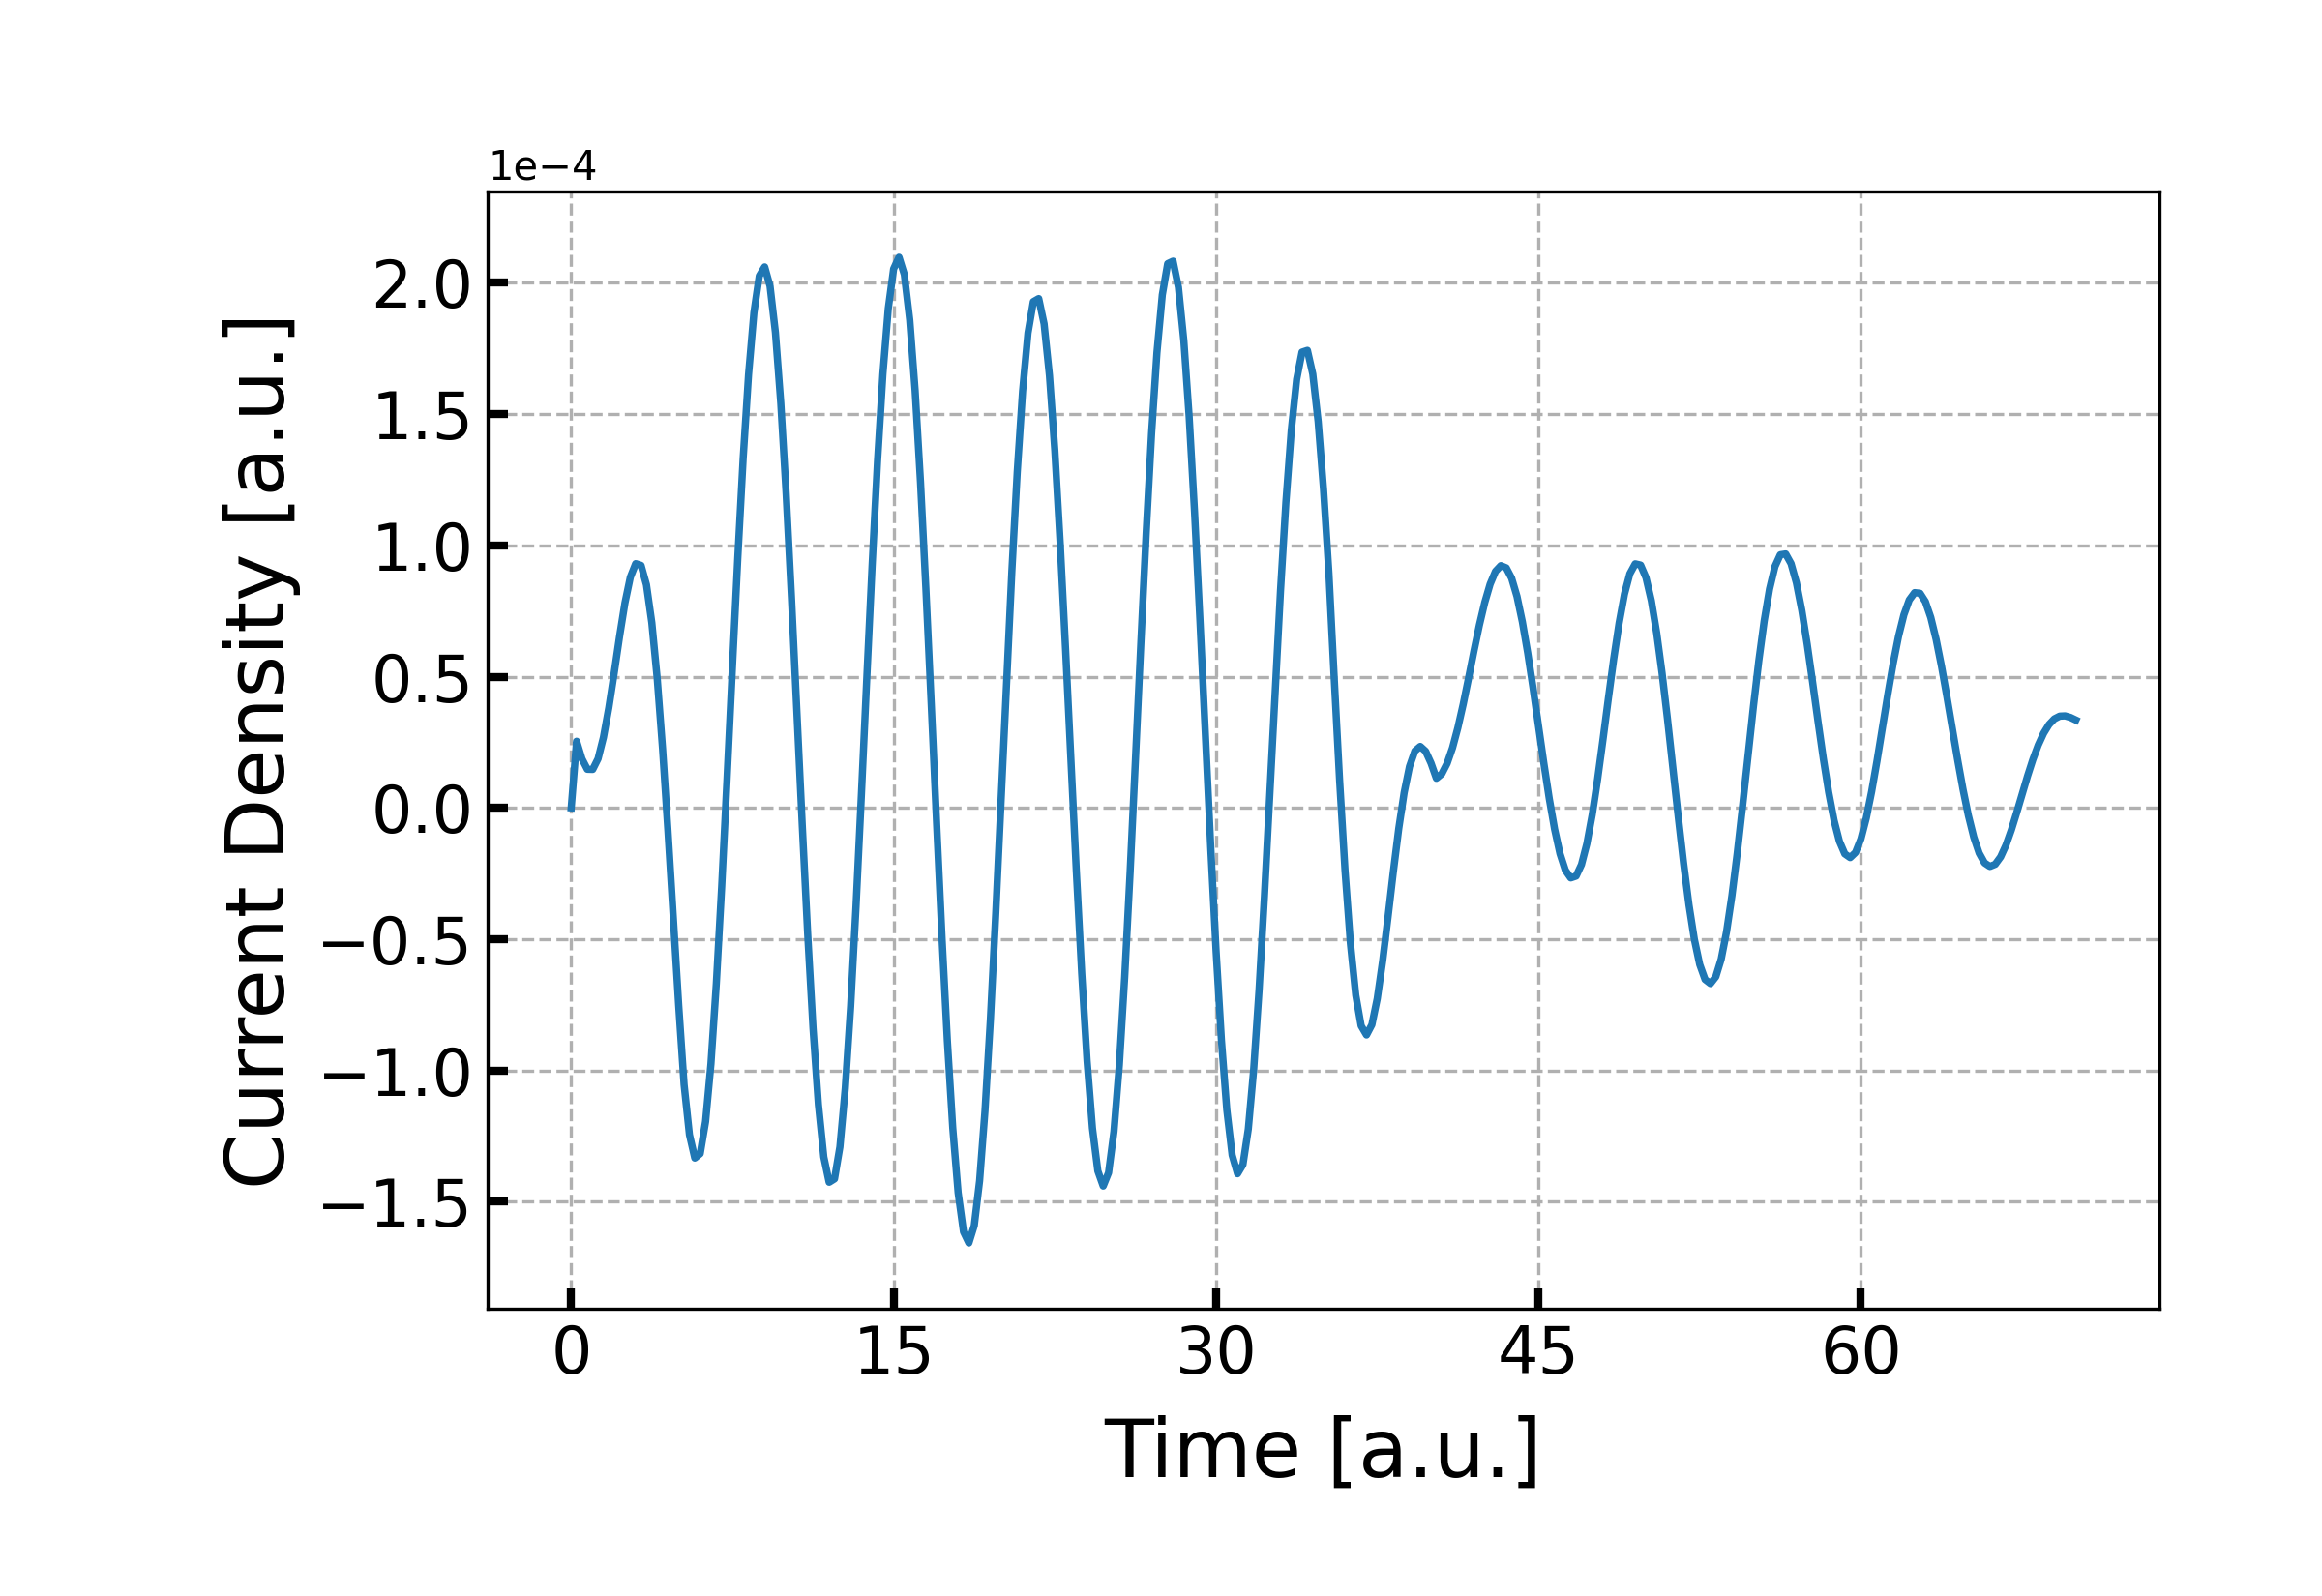
</figure>

You can observe the "in-field" current (for times $t < 40$ a.u.) and the residual current, which are qualitatively different. Note that in realistic calculations, the results should be converged with respect to the $\mathbf{k}$-grid density (<code><span style="color:mediumblue">ngridk</span></code> in <code><span style="color:green">xs</span></code>), the basis size (<code><span style="color:mediumblue">rgkmax</span></code> in <code><span style="color:green">xs</span></code>), and the time step (<code><span style="color:mediumblue">timeStep</span></code> in <code><span style="color:green">realTimeTDDFT</span></code>).

<a id='2.2.2'></a>
**<span style="color:#15317E">2.2.2 Calculations with **unperturbedKS** basis set</span>**

To run a calculation using the **unperturbedKS** basis set, copy the necessary files generated by the ground-state calculation into the new subdirectory `ks_basis_tutorial`:

In [ ]:
%%bash -l
cd run_ks_basis_tutorial
mkdir -p diamond_rt_ks
cp diamond_rt_lapwlo/{input.xml,EFERMI.OUT,STATE.OUT} diamond_rt_ks



Modify the **input.xml** by adding the attribute <code><span style="color:mediumblue">basis</span>=<span style="color:firebrick">"unperturbedKS"</span></code> inside the <code><span style="color:green">realTimeTDDFT</span></code> element to employ the **KS** basis set instead of the **LAPW+LO** set:

```xml
...
   <realTimeTDDFT
...
         eeInteraction="IPA"
         basis="unperturbedKS">
         <laser>
...

```

In [ ]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingXSInput

parsed_input = ExcitingInputXML.from_xml('run_ks_basis_tutorial/diamond_rt_lapwlo/input.xml')
parsed_input.xs.realTimeTDDFT.basis="unperturbedKS"

parsed_input.write('run_ks_basis_tutorial/diamond_rt_ks/input.xml')

Now you can launch the **RT-TDKS** calculation using the same script as before:

In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/diamond_rt_ks

The last calculation should run much faster. You can examine the **TIMING_RTTDDFT.OUT** files for both runs to compare time required for each propagation step.

To plot the $x$-component of the current obtained using **KS** basis size along the one calculated previously, execute the following command:

In [ ]:
%%bash -l
cd run_ks_basis_tutorial/diamond_rt_ks
cp ../diamond_rt_lapwlo/CURRENT.OUT LAPWLO
cp CURRENT.OUT KS
python3 -m excitingscripts.plot.multitask --jind -f LAPWLO KS --x --plot_name JIND_LAPWLO_KS

In file **JIND_LAPWLO_KS.png**, you should see a plot similar to this:

<figure>
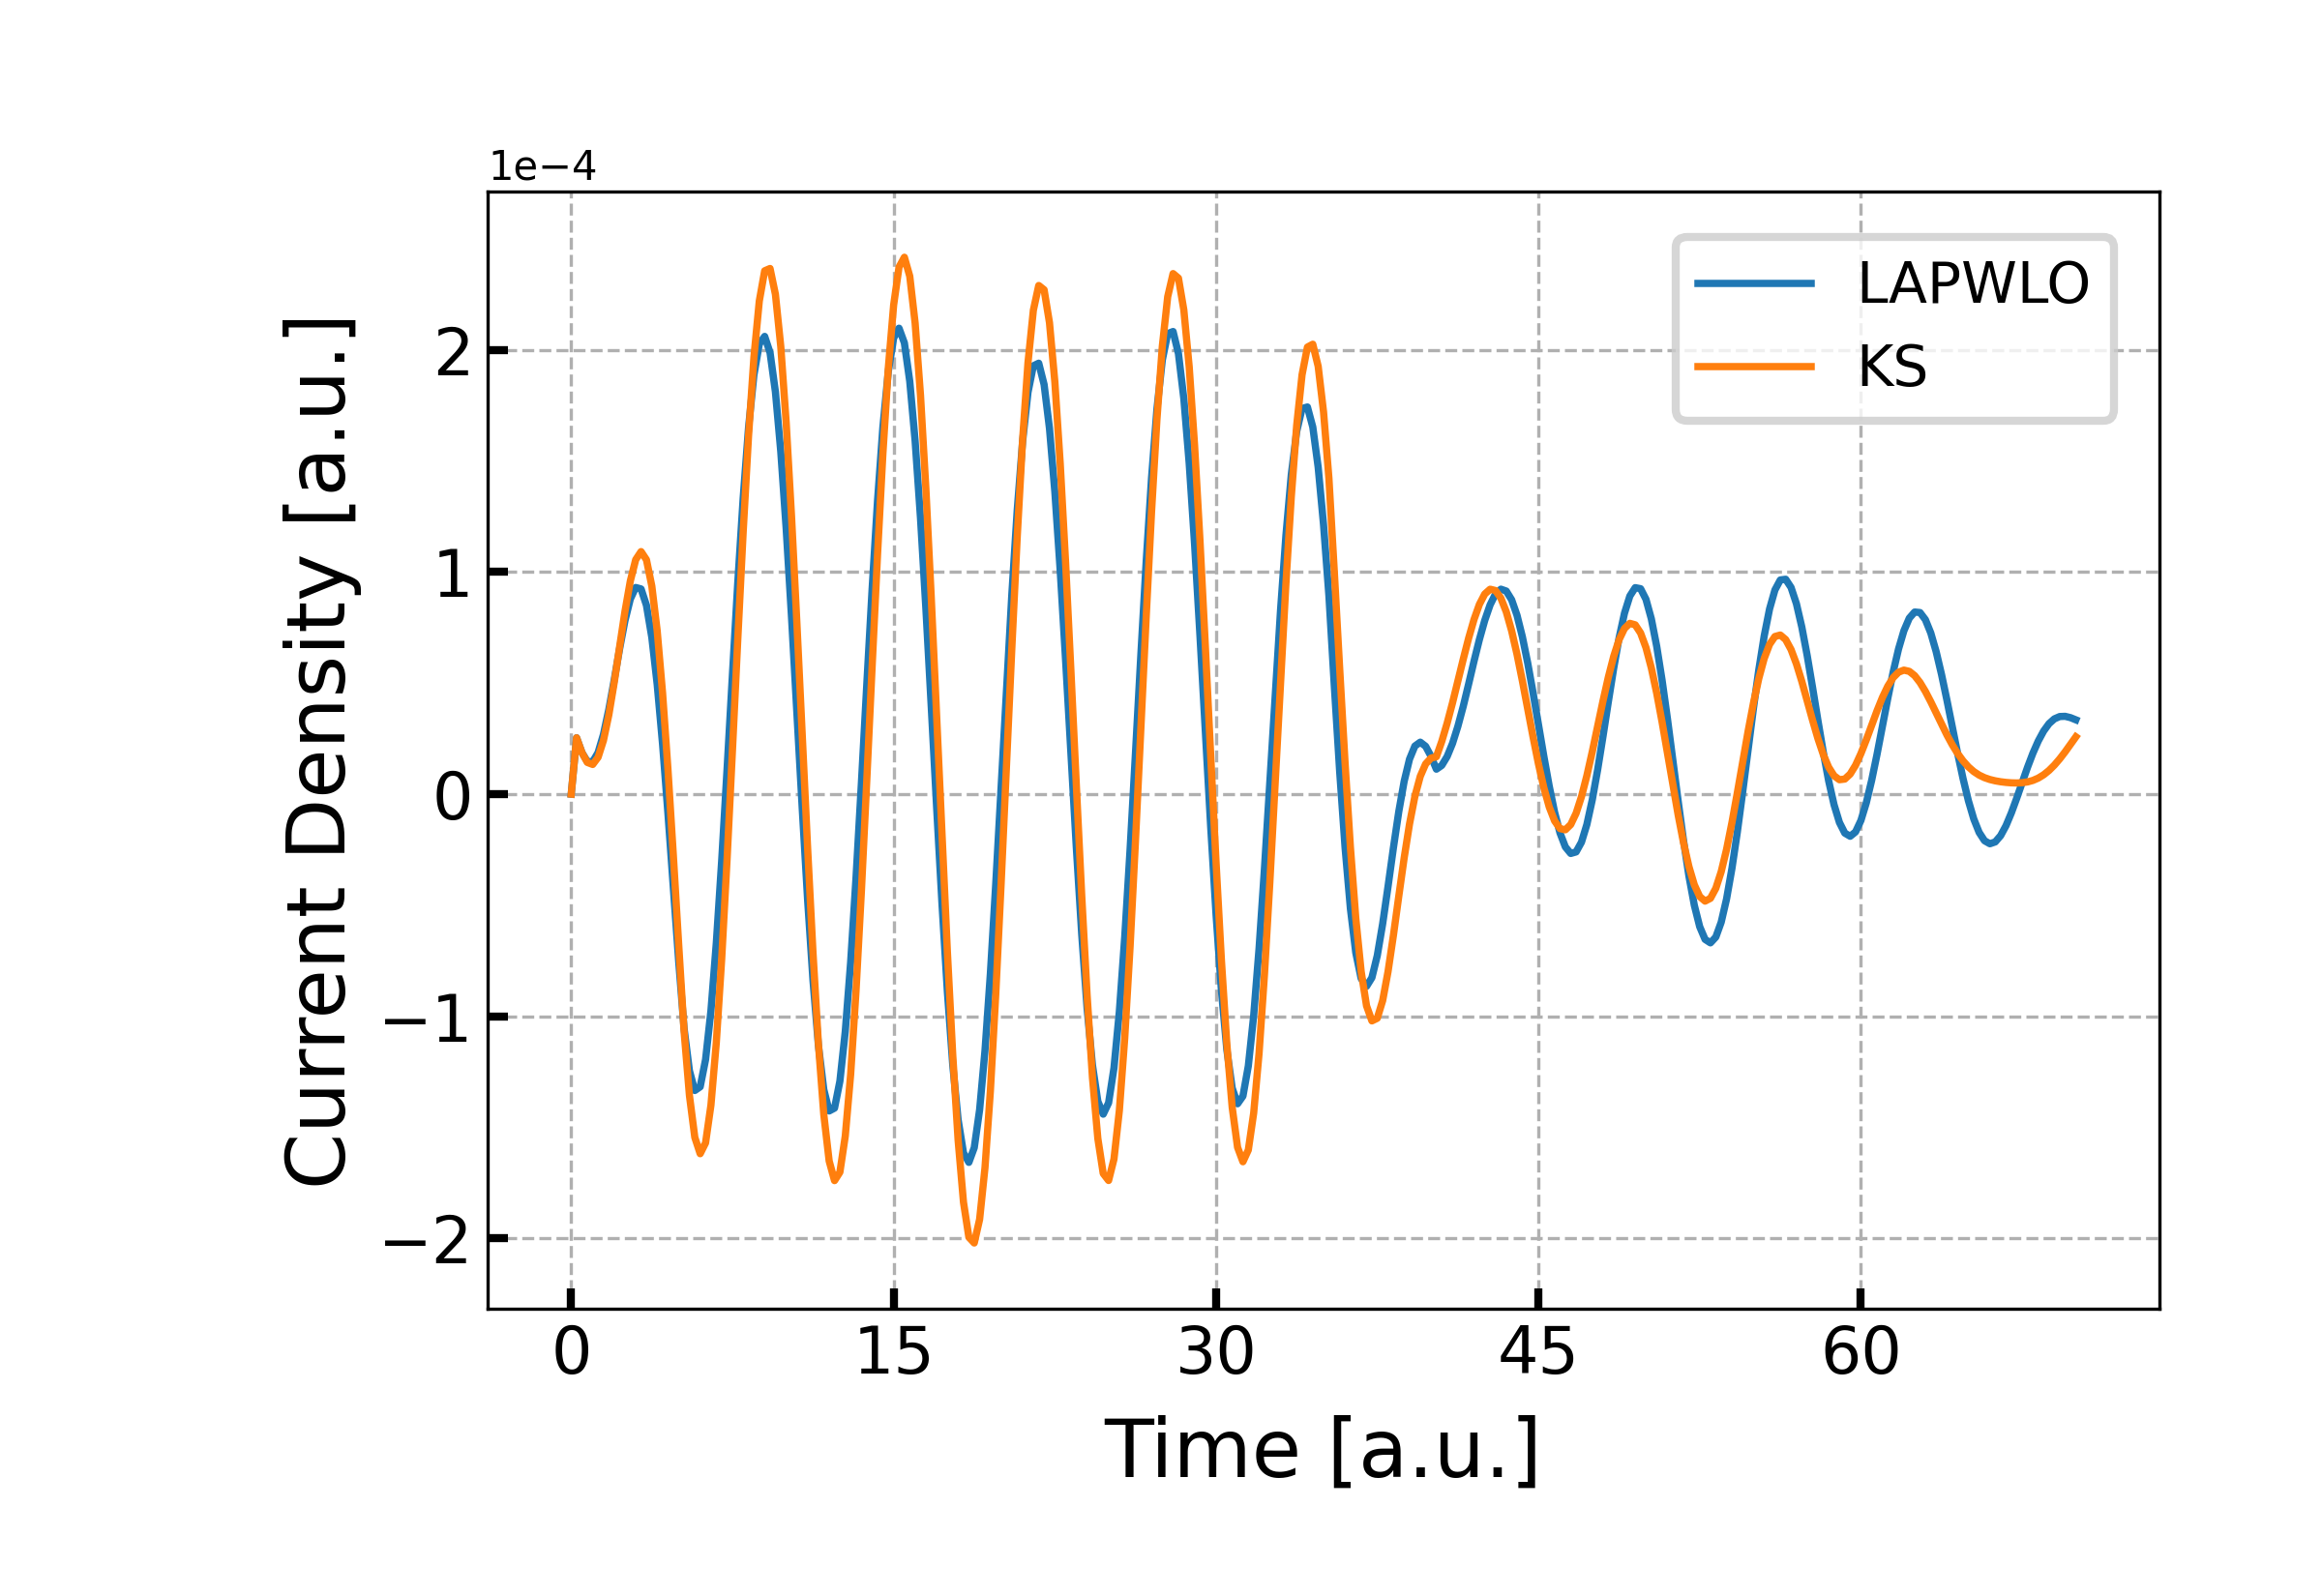
</figure>

As you can see, the results are differ due to the different basis set sizes used in the two calculations.

 The **KS** basis size $N_{\scriptscriptstyle \textrm{KS}} = N_{\rm occupied} + N_{\rm empty}$ is controlled by the <code><span style="color:mediumblue">nempty</span></code> attribute inside the <code><span style="color:green">xs</span></code> element (as you saw from the ground-state results, $N_{\rm occupied} = 4$ in our case). Note that <code><span style="color:mediumblue">nempty</span></code> parameter inside the <code><span style="color:green">groundstate</span></code> element is not used in **RT-TDDFT** calculations.

 If <code><span style="color:mediumblue">nempty</span></code> is not provided in **input.xml**, it is set to $5$ by default. As mentioned before, in **``exciting``** $N_{\rm empty} = $ <code><span style="color:mediumblue">nempty</span></code> $+ 1$. Therefore, the previous calculation used $N_{\scriptscriptstyle \textrm{KS}} = 4 + 5 + 1 = 10$ basis functions. With **LAPW+LO**, approximately $70$ basis functions were employed, providing better numerical precision.

<a id='2.2.3'></a>
**<span style="color:#15317E">2.2.3 Increasing the **unperturbedKS** basis size</span>**


To increase the basis size, modify the **input.xml** in the **diamond_rt_ks** subdirectory, changing the <code><span style="color:mediumblue">nempty</span></code> parameter from $5$ to $20$:
```xml
...
   <xs 
...
      reducek="false"
      nempty="20">
...
   </xs>
...

```

In [ ]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML

parsed_input = ExcitingInputXML.from_xml('run_ks_basis_tutorial/diamond_rt_ks/input.xml')
parsed_input.xs.nempty=20


parsed_input.write('run_ks_basis_tutorial/diamond_rt_ks/input.xml')

And run **``exciting``** again:

In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/diamond_rt_ks

Once the calculation has finished, you can plot all three current densities together in the same file **JIND_ALL.png**:

In [ ]:
%%bash -l
cd run_ks_basis_tutorial/diamond_rt_ks
cp ../diamond_rt_lapwlo/CURRENT.OUT LAPWLO
cp CURRENT.OUT KS_increased_basis_size
python3 -m excitingscripts.plot.multitask --jind -f LAPWLO KS KS_increased_basis_size --x --plot_name JIND_ALL
cd ../../

As the figure shows, the **LAPWLO** and **KS_increased_basis_size** curves now nearly indistinguishable.

<figure>
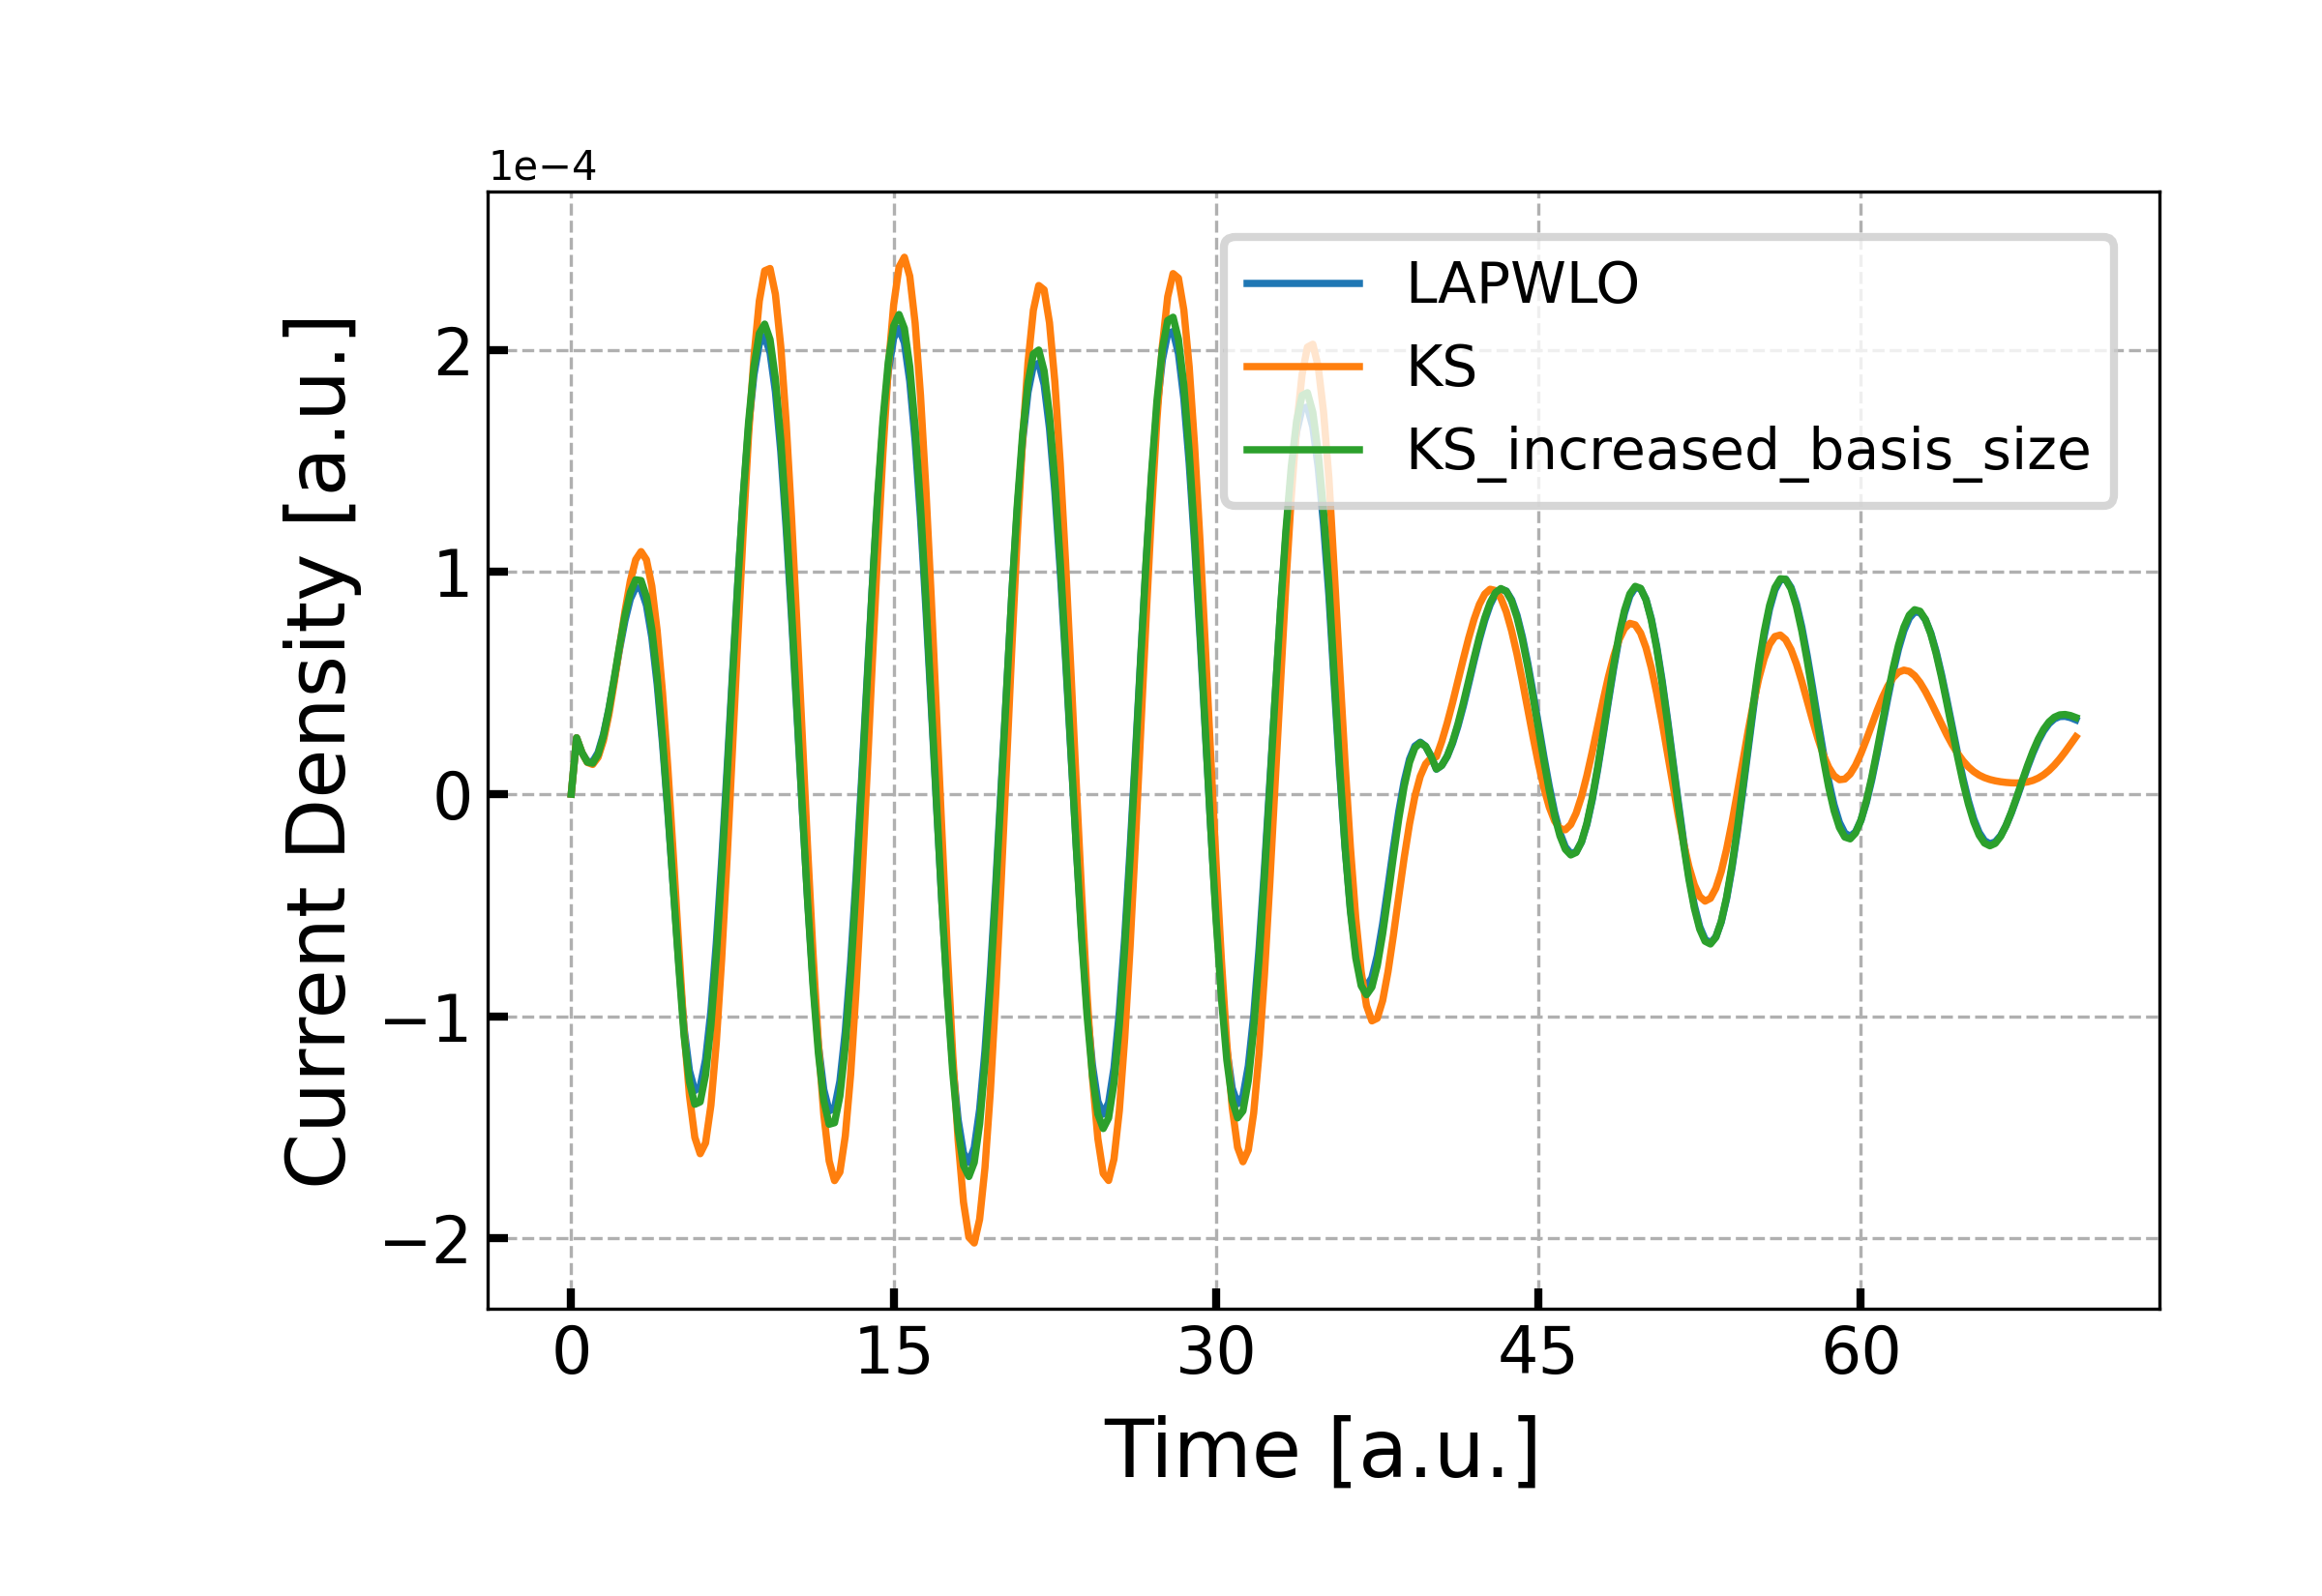
</figure>

**<span style="color:firebrick">Please note</span>**: For production calculations, results obtained using the **KS** basis must be systematically converged with respect to the basis size. This is controlled by the <code><span style="color:mediumblue">nempty</span></code> parameter within the <code><span style="color:green">xs</span></code> element.

<hr style="border:2px solid #DDD"> </hr>

### <span style="color:#15317E">3. Monolayer BN</span>

After learning the basics of how to use the ground-state **KS** wavefunctions as a basis, we now consider the case of a two-dimensional material: monolayer BN. Low dimensional systems, such as isolated molecules, nanowires, and two-dimensional materials, are expected to benefit the most from using the **KS** basis, compared to bulk systems **[<span style="color:firebrick">[1]</span>](#7)**. 

In this part of the tutorial, we take advantage of the fast calculations enabled by employing ground-state **KS** wavefunctions as the basis. Our goal is to examine the different responses of monolayer BN subjected to a laser pulse. Specifically, we will determine the number of excited electrons as a function of the laser's
- polarization,
- pulse duration, and
- central frequency.

<a id='3.1'></a>
**<span style="color:#15317E">3.1 Ground-state calculation</span>**

First, a ground-state calculation of monolayer BN must be performed.
Create a separate directory:

In [ ]:
%%bash -l
mkdir -p run_ks_basis_tutorial/BN_gs

containing the following **input.xml** file:

<span class="BN_monolayer"></span>
```xml
<input>
 
   <title>BN_monolayer</title>
 
   <structure speciespath="$EXCITINGROOT/species/">
      <crystal scale="4.72">
         <basevect>  0.5  0.86602540378   0.0 </basevect>
         <basevect> -0.5  0.86602540378   0.0 </basevect>
         <basevect>  0.0  0.00000000000   3.0 </basevect>
      </crystal>
      <species speciesfile="B.xml" rmt="1.35">
         <atom coord="0.000000  0.000000  0.0"/>
      </species>
      <species speciesfile="N.xml"  rmt="1.35">
         <atom coord="0.333333  0.333333  0.0"/>
      </species>
   </structure>
 
   <groundstate
      do="fromscratch"
      xctype="LDA_PW"
      ngridk="6 6 1"
      rgkmax="4.0d0"
      gmaxvr="10.0d0"
      epsengy="1.d-4">
   </groundstate>   
 
</input>
```

In [ ]:
from excitingjupyter.utilities import get_input_xml_from_notebook

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("ks_basis_in_real_time_tddft", "BN_monolayer")

# Write out the input as an XML file:
with open('./run_ks_basis_tutorial/BN_gs/input.xml', "w") as fid:
    fid.write(input_str)

**<span style="color:firebrick">Please note</span>** that the previous setup is intended for **illustrative purposes only**, as this setup is **not expected to be converged**.

Now, replace **$EXCITINGROOT** with its actual value.

In [ ]:
%%bash -l
cd run_ks_basis_tutorial/BN_gs
python3 -m excitingscripts.setup.excitingroot
cd ../..

Then, run the ground-state calculation:

In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/BN_gs

<a id='3.2'></a>
**<span style="color:#15317E">3.2 Monolayer BN exposed to a laser pulse</span>**

We now analyze the time-dependent response of the BN monolayer to a laser pulse using the **KS** under various scenarios, by modifying the:
1. Polarization of the laser field;
2. Duration of the laser pulse; and
3. The central frequency of the laser pulse.

We start with a monolayer BN exposed to a **x**-polarized cosine wave modulated by a trapezoid, with pulse duration of 10 a.u. and frequency of 1.0 a.u.

The **input.xml** file is as follows:

```xml
<input>
...
   <groundstate 
      do="skip"
      ... >
   </groundstate>
   <xs 
      xstype="RT-TDDFT"
      ngridk="6 6 1"
      vkloff="0.01 0.02 0.004"
      nempty="20"
      nosym="true"
      reducek="false">
      <realTimeTDDFT
         propagator="SE"
         timeStep="0.2d0"
         endTime="15.d0"
         printTimingGeneral="true"
         calculateNExcitedElectrons="true"
         calculateTotalEnergy="true"
         printAfterIterations="10"
         eeInteraction="IPA"
         basis="unperturbedKS">
         <laser>
            <trapCos 
               amplitude="1.0d0" omega="1.0d0" phase="0.d0"
               t0="0.0d0" riseTime="1.d0" width="10.d0" 
               direction="x" />
         </laser>
         <pmat readFromFile="false" writeToFile="false" forceHermitian="true" />
      </realTimeTDDFT>
   </xs>
</input>
```

**<span style="color:firebrick">Please note</span>** that the previous setup is intended for **illustrative purposes only**, to allow for fast calculations: it is **not expected to be converged**.

As for the case of diamond, create a new directory, and copy the following files from the ground-state calculation of BN:
- **input.xml**
- **EFERMI.OUT**
- **STATE.OUT**

This can be done with the following commands:

In [ ]:
%%bash -l
mkdir -p run_ks_basis_tutorial/BN_rt
cp run_ks_basis_tutorial/BN_gs/{input.xml,EFERMI.OUT,STATE.OUT} run_ks_basis_tutorial/BN_rt

Then adjust the **input.xml** file as shown above. 

In [ ]:
from excitingtools import ExcitingInputXML, ExcitingXSInput

parsed_input = ExcitingInputXML.from_xml('run_ks_basis_tutorial/BN_rt/input.xml')

xs = {'xstype': 'RT-TDDFT',
      'ngridk': [6, 6, 1],
      'vkloff': [0.01, 0.02, 0.004],
      'nempty': 20,
      'nosym': True,
      'reducek': False,
      'realTimeTDDFT': {'propagator': 'SE', 'timeStep': 0.25, 'endTime': 15.0, 'printTimingGeneral': True,
                        'calculateNExcitedElectrons': True, 
                        'printAfterIterations': 10, 'eeInteraction': 'IPA', 'basis': 'unperturbedKS',
                        'pmat': {'readFromFile': False, 'writeToFile': False, 'forceHermitian': True},
                        'laser': {'trapCos': [{'amplitude': 1.0, 'omega': 1.0, 'phase': 0.0, 't0': 0.0,
                                               'riseTime': 1.0, 'width': 10.0, 'direction': 'x'}]}}}

parsed_input.xs = ExcitingXSInput(**xs)
parsed_input.groundstate.do = "skip"

parsed_input.write('run_ks_basis_tutorial/BN_rt/input.xml')

To run the calculation with the polarization along the $x$ direction, use the command:

In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/BN_rt
cp run_ks_basis_tutorial/BN_rt/{N_EXCITATIONS.OUT,x}

Now, adjust the **input.xml** file to change the polarization of the laser field to the $z$ direction by modifying the <code><span style="color:mediumblue">direction</span></code> attribute in the <code><span style="color:green">trapCos</span></code> element.
```xml
<input>
...
   <xs 
      ...>
      <realTimeTDDFT
         ...>
         <laser>
            <trapCos 
               ...
               direction="z" />
         </laser>
         ...
      </realTimeTDDFT>
   </xs>
</input>
```

In [ ]:
from excitingtools import ExcitingInputXML

parsed_input = ExcitingInputXML.from_xml('run_ks_basis_tutorial/BN_rt/input.xml')
parsed_input.xs.realTimeTDDFT.laser.trapCos[0].direction = 'z'

parsed_input.write('run_ks_basis_tutorial/BN_rt/input.xml')

Run the calculation again with the command:

In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/BN_rt
cp run_ks_basis_tutorial/BN_rt/{N_EXCITATIONS.OUT,z}

In the next step, modify <code><span style="color:mediumblue">width</span></code> attribute in the <code><span style="color:green">trapCos</span></code> element to 5.0 a.u.
```xml
<input>
...
   <xs 
      ...>
      <realTimeTDDFT
         ...>
         <laser>
            <trapCos 
               ...
               width="5.0" />
         </laser>
         ...
      </realTimeTDDFT>
   </xs>
</input>
```

In [ ]:
from excitingtools import ExcitingInputXML

parsed_input = ExcitingInputXML.from_xml('run_ks_basis_tutorial/BN_rt/input.xml')
parsed_input.xs.realTimeTDDFT.laser.trapCos[0].width = 5.0

parsed_input.write('run_ks_basis_tutorial/BN_rt/input.xml')

Then, run the calculation for this new setup with:

In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/BN_rt
cp run_ks_basis_tutorial/BN_rt/{N_EXCITATIONS.OUT,z_width_5}

Finally, restore <code><span style="color:mediumblue">width</span>=<span style="color:firebrick">"10.0"</span></code> and modify the <code><span style="color:mediumblue">omega</span></code> attribute to 0.8 a.u. To keep the peak intensity of the laser pulse unchanged, the <code><span style="color:mediumblue">amplitude</span></code> attribute must be adjusted accordingly to 1.5625 a.u.
```xml
<input>
...
   <xs 
      ...>
      <realTimeTDDFT
         ...>
         <laser>
            <trapCos 
               ... 
               amplitude="1.5625d0" omega="0.8d0" width="5.0" />
         </laser>
         ...
      </realTimeTDDFT>
   </xs>
</input>
```

In [ ]:
from excitingtools import ExcitingInputXML

parsed_input = ExcitingInputXML.from_xml('run_ks_basis_tutorial/BN_rt/input.xml')
parsed_input.xs.realTimeTDDFT.laser.trapCos[0].width = 10.0
parsed_input.xs.realTimeTDDFT.laser.trapCos[0].omega = 0.8
parsed_input.xs.realTimeTDDFT.laser.trapCos[0].amplitude = 1./0.8**2

parsed_input.write('run_ks_basis_tutorial/BN_rt/input.xml')

Run the calculation again with the command:

In [ ]:
%%bash -l
python3 -m excitingscripts.execute.single -r run_ks_basis_tutorial/BN_rt
cp run_ks_basis_tutorial/BN_rt/{N_EXCITATIONS.OUT,z_omega_0.8}

The results of the four previous calculations can be visualized using:

In [ ]:
%%bash -l
cd run_ks_basis_tutorial/BN_rt
python3 -m excitingscripts.plot.multitask --nexc -f x z z_width_5 z_omega_0.8 --plot_name NEXC
cd ../../

Your figure should be similar to:

<figure>
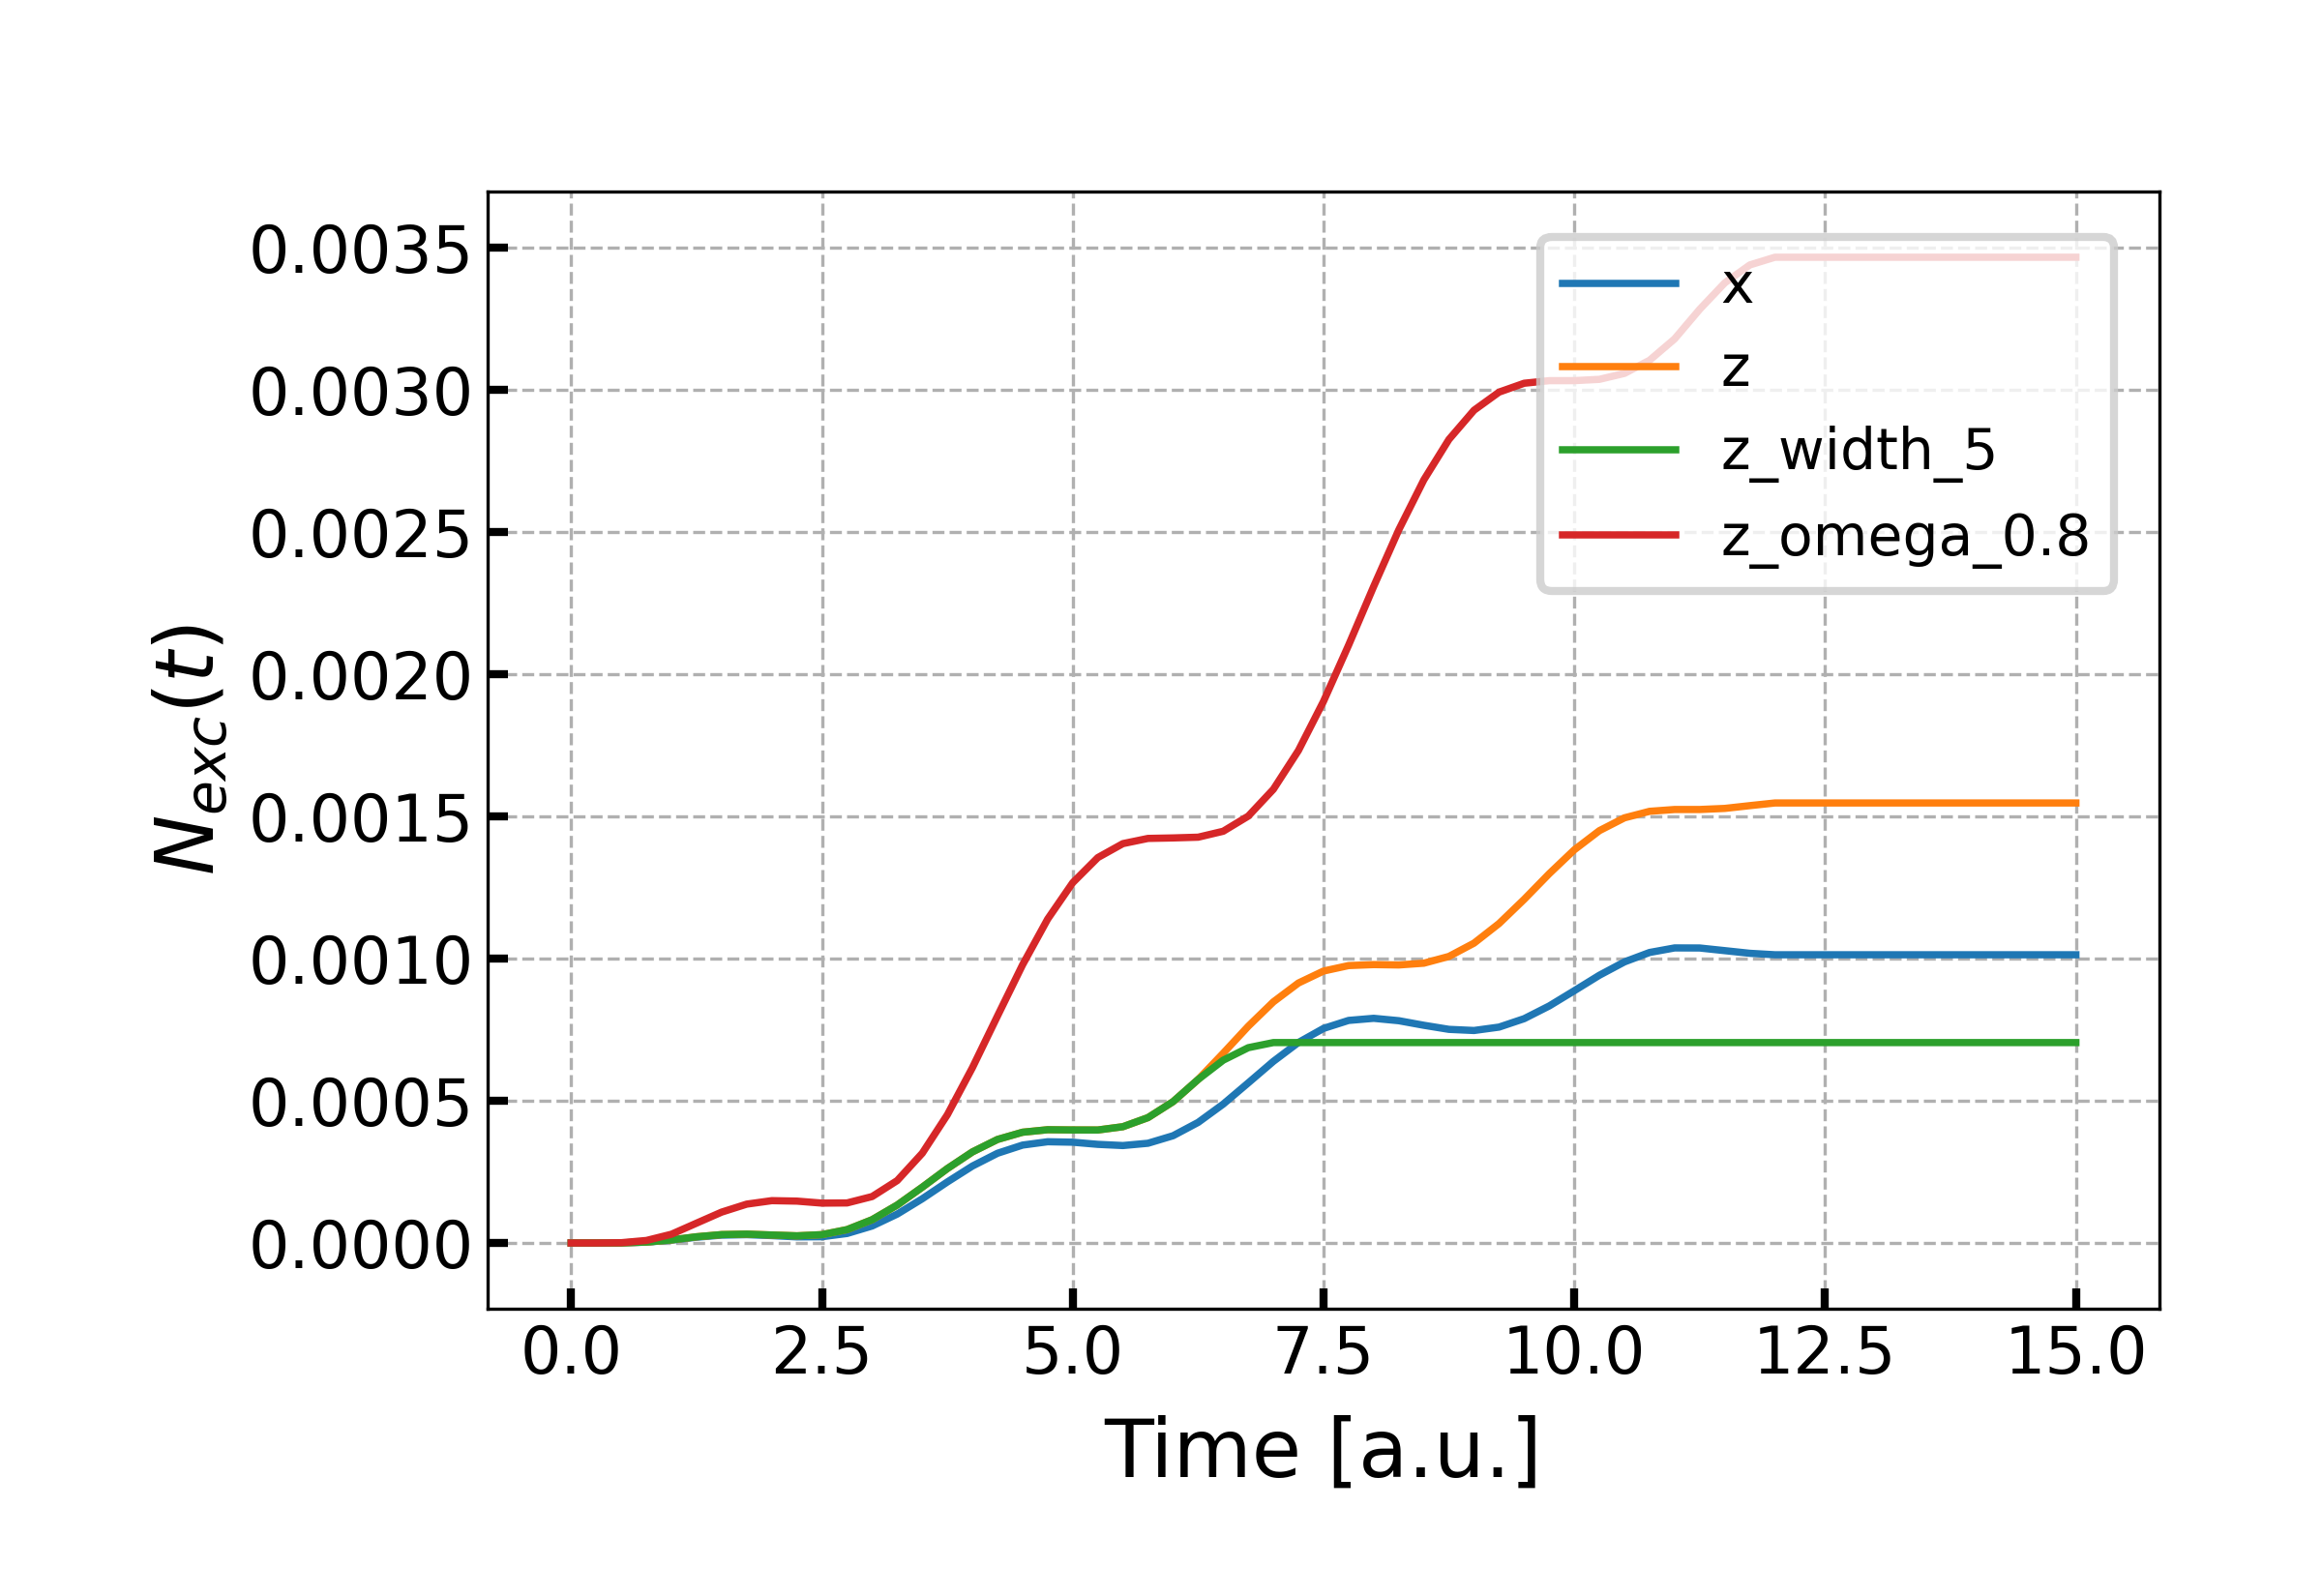
</figure>

**<span style="color:green">Exercise</span>**

- Run one of the calculations above using the **LAPW+LO** basis set and determine the speed-up achieved by using unperturbed KS states as the basis.

<hr style="border:2px solid #DDD"> </hr>

### <span style="color:#15317E">Reference</span>

The details on the implementation of the **KS** basis set for **RT-TDDFT** in **`exciting`** can be found in **[<span style="color:firebrick">Ref.[1]</span>](#7)**.
<hr style="border:1px solid #DDD"> </hr>

<a id='7'></a>
### <span style="color:#15317E">Bibliography</span>

1. Ronaldo Rodrigues Pela, Claudia Draxl. "Speeding up all-electron real-time TDDFT demonstrated by the exciting package" (**[link](https://doi.org/10.1016/j.cpc.2024.109292)**).

<hr style="border:2px solid #DDD"> </hr>